<left><img width=25% src="img/gw_monogram_2c.png"></left>

# Lecture 12: Decision Trees

### ECE6210 Machine Intelligence

__Armin Mehrabian__<br>The George Washington University


# Lecture Objectives

* Represent predictions using decision rules and tree regions.
* Explain greedy tree construction and impurity measures.
* Identify the high-variance behavior of deep trees.
* Explain how random forests reduce variance.


# Part 1: Decision Trees

We are now going to see a different way of defining machine models called *decision trees*.

# Review: Components of A Supervised Machine Learning Problem

At a high level, a supervised machine learning problem has the following structure:

$$ \underbrace{\text{Training Dataset}}_\text{Attributes + Features} + \underbrace{\text{Learning Algorithm}}_\text{Model Class + Objective + Optimizer } \to \text{Predictive Model} $$

# Gas-Sensor Classification

We begin with a binary classification task. The model detects ammonia using four normalized steady-state sensor features.


In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

try:
    from slides.course_data import load_gas_sensor_drift
except ModuleNotFoundError:
    from course_data import load_gas_sensor_drift

gas_binary_data = load_gas_sensor_drift(as_frame=True)
binary_feature_indices = [1, 33, 65, 97]
binary_feature_names = gas_binary_data.feature_names[binary_feature_indices].tolist()
binary_target_all = (gas_binary_data.target.to_numpy() == 2).astype(int)

rng = np.random.default_rng(31)
positive_indices = np.flatnonzero(binary_target_all == 1)
negative_indices = np.flatnonzero(binary_target_all == 0)
sample_indices = np.concatenate([
    rng.choice(positive_indices, 700, replace=False),
    rng.choice(negative_indices, 700, replace=False),
])

tree_X = gas_binary_data.data.iloc[sample_indices, binary_feature_indices]
tree_y = binary_target_all[sample_indices]
print("Features:", binary_feature_names)


The first rows show four sensor features. The target is one for ammonia and zero for the other gases.


In [ ]:
tree_table = tree_X.copy()
tree_table["ammonia"] = tree_y
tree_table.head()


# Decision Trees: Basic Idea

A decision tree applies a sequence of threshold rules.

1. Select a feature and threshold.
2. Divide the measurements into two groups.
3. Repeat the procedure within each group.
4. Assign a prediction to every terminal group.

The learned rules are determined by the training objective.


# Decision Tree Example

We fit a depth-two tree for ammonia detection.


We will train a decision tree using its implementation in `sklearn`.

In [ ]:
clf = DecisionTreeClassifier(max_depth=2, random_state=4)
clf.fit(tree_X, tree_y)

plt.figure(figsize=(14, 6))
plot_tree(
    clf,
    feature_names=binary_feature_names,
    class_names=["Other gas", "Ammonia"],
    filled=True,
    impurity=False,
)
plt.show()


# Decision Rules

A decision rule $r:\mathcal{X}\to\{\text{true},\text{false}\}$ divides the feature space into two regions. For a sensor feature $x_j$ and threshold $t$,

$$r(x)=\begin{cases}
\text{true} & \text{if } x_j\leq t,\\
\text{false} & \text{if } x_j>t.
\end{cases}$$

Continuous-feature rules normally use one threshold at a time.


# Decision Trees: Definition

A decision tree is a (usually binary) tree, where: 

* Each internal node $n$ corresponds to a rule $r_n$

* The $j$-th edge out of $n$ is associated with a rule value $v_j$, and we follow the $j$-th edge if $r_n(x)=v_j$

* Each leaf node $l$ contains a prediction $f(x)$

* Given input $x$, we start at the root, apply its rule, follow the eddge that corresponds to the outcome, and repeat recursively.

In [ ]:
plt.figure(figsize=(14, 6))
plot_tree(
    clf,
    feature_names=binary_feature_names,
    class_names=["Other gas", "Ammonia"],
    filled=True,
    impurity=False,
)
plt.show()


# Decision Regions

Decision trees partition the feature space into regions. A region $R\subseteq\mathcal{X}$ is defined by a sequence of rule outcomes:

$$R=\{x\in\mathcal{X}\mid r_1(x)=v_1,\ldots,r_m(x)=v_m\}.$$

For example, a sensor region may require one normalized response to be below a threshold and another response to be above a second threshold.


We can illustrate decision regions via this figure from Hastie et al.

<center><img width=50% src="img/decision_tree.png"></center>

The illustrations are as follows:
* Top right: regions that can be represented by a tree
* Bottom left: tree generating the top right regions
* Bottom right: function values assigned to the regions
* Top left: regions that cannot be represented by a tree.

# Decision Trees and Regions

A decision tree can be written as a model $f : \mathcal{X} \to \mathcal{Y}$ of the form
$$ f(x) = \sum_{R \in \mathcal{R}} y_R \mathbb{I}\{x \in R\}. $$
* The $\mathbb{I}\{\cdot\}$ is an indicator function (one if $\{\cdot\}$ is true, else zero) and values $y_R \in \mathcal{Y}$ are the outputs for that region.
* The set $\mathcal{R}$ is a collection of decision regions. They are obtained by a recursive learning procedure (*recursive binary splitting*).
* The rules defining the regions $\mathcal{R}$ can be organized into a tree, with one rule per internal node and regions being the leaves.

# Pros and Cons of Decision Trees

Decision trees are important models in machine learning
* They are highly interpretable.
* Require little data preparation (no rescaling, handle continuous and discrete features).
* Easy to use with categorical data

Their main disadvantages are that:
* If they stay small and interpretable, they are not as powerful.
* If they are large, they easily overfit and are hard to regularize.

<left><img width=25% src="img/gw_monogram_2c.png"></left>
# Part 2: Learning Decision Trees

We saw how decision trees are represented. How do we now learn them from data?


# Recall: Decision Trees

A decision tree is a model $f : \mathcal{X} \to \mathcal{Y}$ of the form
$$ f(x) = \sum_{R \in \mathcal{R}} y_R \mathbb{I}\{x \in R\}. $$
* The $\mathbb{I}\{\cdot\}$ is an indicator function (one if $\{\cdot\}$ is true, else zero) and values $y_R \in \mathcal{Y}$ are the outputs for that region.
* The set $\mathcal{R}$ is a collection of decision regions. They are obtained by *recursive binary splitting*.
* The rules defining the regions $\mathcal{R}$ can be organized into a tree, with one rule per internal node and regions being the leaves.

In [ ]:
plt.figure(figsize=(14, 6))
plot_tree(
    clf,
    feature_names=binary_feature_names,
    class_names=["Other gas", "Ammonia"],
    filled=True,
    impurity=False,
)
plt.show()


We can also illustrate decision trees via this figure from Hastie et al.

<left><img width=50% src="img/decision_tree.png"></left>

# Learning Decision Trees

At a high level, decision trees are grown by adding nodes one at a time.

```python
def build_tree():
    whlie tree.is_complete() is False:
        leaf, leaf_data = tree.get_leaf()
        new_rule = create_rule(leaf_data)
        tree.append_rule(leaf, new_rule)
```

Most often, we build the tree until it reaches a maximum number of nodes. The crux of the algorithm is in `create_rule`.

# Learning New Decision Rules

What is the set of possible rules that `create_rule` can add to the tree? 

When $x$ has continuous features, the rules have the following form:

$$ r(x) = \begin{cases}\text{true} & \text{if } x_j \leq t \\ \text{false} & \text{if } x_j > t \end{cases} $$

for a feature index $j$ and threshold $t \in \mathbb{R}$.

When $x$ has categorial features, rules may have the following form:
$$ r(x) = \begin{cases}\text{true} & \text{if } x_j = t_k \\ \text{false} & \text{if } x_j \neq t_k \end{cases} $$
for a feature index $j$ and possible value $t_k$ for $x_j$.

# Learning New Decision Rules

How does the `create_rule` function choose new rule $r$? Let's say that $R$ is the region of a leaf and $\mathcal{D}_R = \{(x^{(i)}, y^{(i)}\mid x^{(i)} \in R \}$ is the data for $R$.

We add to the leaf a new rule $r : \mathcal{X} \to \{T, F\}$ that minimizes a loss:
$$ \min_{r \in \mathcal{U}} \left( \underbrace{L(\{(x, y) \in \mathcal{D}_R \mid r(x) = \text{T}\})}_\text{left subtree} +  \underbrace{L(\{(x, y) \in \mathcal{D}_R \mid r(x) = \text{F}\}}_\text{right subtree})\right) $$

where $L$ is a loss function over a subset of the data flagged by the rule and $\mathcal{U}$ is the set of possible rules.

Which is the best split given the data with two classes?
<left><img width=50% src="img/dt-1.png"></left>

* The goodness of split is measured by an impurity function
* defined for each node
* Intuitively, we want each leaf node to be “pure”, that is, one class dominates.
<left><img width=50% src="img/dt-2.png"></left>

* How to determine the Best Split?

* Nodes with homogeneous class distribution are preferred


* Need a measure of node impurity. Imagine we have 10 data points and we make a split
    * C1 (5) - C2 (5) --> impure
    * C2 (9) - C2 (1) --> more pure

Simple Impurity measure
* Relative fraction of each class
* What's Problem with that?


Measures of Impurity:

1. Information Gain based on Entropy
2. Gini Index

# Information Gain in Decision Trees

Decision trees use various metrics to determine the best split at each node. One commonly used metric is *Information Gain*, which is based on the concept of Entropy.

## Entropy

Entropy measures the uncertainty or impurity in a group of examples. The entropy of a set $ S $ is calculated as:

$$
\text{Entropy}(S) = -\sum_{v \in V} p(v) \log(p(v))
$$

- $ V $ are the distinct values that the target attribute can take.
- $ p(v) $ is the proportion of the number of elements in class $ v $ to the number of elements in set $ S $.

## Information Gain

Information Gain is the decrease in entropy after a dataset is split on an attribute. It measures how well a given attribute separates the training examples according to their target classification. The Information Gain $ \text{Gain}(S, A) $ for an attribute $ A $ is defined as:

$$
\text{Gain}(S, A) = \text{Entropy}(S) - \sum_{v \in V} \left( \frac{|S_v|}{|S|} \right) \text{Entropy}(S_v)
$$

- $ S_v $ is the subset of $ S $ where attribute $ A $ has the value $ v $.
- $ |S_v| $ is the size of the subset $ S_v $.
- $ |S| $ is the size of the set $ S $.

### Calculation Process

To calculate the Information Gain of an attribute \( A \):

1. Calculate the entropy for the entire set \( S \).
2. For each value \( v \) that the attribute \( A \) can take:
   - Partition \( S \) into subsets \( S_v \).
   - Calculate the entropy of each subset \( S_v \).
   - Multiply the entropy of each subset by the proportion of the number of elements in \( S_v \) to the number of elements in \( S \).
3. Sum these values and subtract from the original entropy to determine the Information Gain for attribute \( A \).

The attribute with the highest Information Gain is used to make the split in the decision tree at the current node.


if F is a feature with two possible values 0 and 1, and p0=1 and p1=0, then we get no new information from knowing that F=+1 for a given example. Thus the entropy is zero. If p1=0.5 and p2=0.5, then the entropy is at maximum.!

<left><img width=50% src="img/dt-entropy.png"></left>

<left><img width=50% src="img/dt-entropy-2.png"></left>

# Entropy at a Given Node \( t \)

Entropy at a node in a decision tree is a measure of the randomness or disorder at that point. It reflects the homogeneity of the examples at the node.

## Entropy Equation

For a given node \( t \), the entropy can be defined as:

$$
\text{Entropy}(t) = -\sum_{j} p(j | t) \log p(j | t)
$$

- $ p(j | t) $ is the relative frequency of class \( j \) at node \( t \).

### Interpretation

- The **maximum entropy** is $ \log(n_c) $, where $ nc $ is the number of classes. This maximum value occurs when the records are evenly distributed among all classes, implying that there is the least amount of information gained from any split at this node.
- The **minimum entropy** is 0.0, which occurs when all records at node $ t $ belong to one class, implying that the node is perfectly homogeneous, and there is the most amount of information to be gained.
  

### Example of calculating Entropy

<left><img width=70% src="img/dt-sample-entropy.png"></left>


# Information Gain of a Split

Information Gain measures the change in entropy that results from splitting a dataset on an attribute. It is an essential metric in the construction of decision trees.

## Definition of Information Gain

When a parent node \( p \) is split into \( k \) partitions, with \( n_i \) representing the number of records in the \( i^{th} \) partition, the Information Gain (\( \text{Gain} \)) is calculated as the reduction in entropy brought about by the split. The formula is given by:

$$
\text{Gain}(p) = \text{Entropy}(p) - \sum_{i=1}^{k} \left( \frac{n_i}{N} \right) \text{Entropy}(i)
$$

- $ \text{Entropy}(p) $ represents the entropy of the parent node.
- $ \text{Entropy}(i) $ denotes the entropy of the $ i^{th} $ partition.
- $ N $ is the total number of records at the parent node.
- $ \frac{n_i}{N} $ is the proportion of records in the $ i^{th} $ partition relative to the total.

## Criteria for Split Selection

- The aim is to select the split that achieves the maximum Information Gain, thereby reducing uncertainty the most.
- Algorithms such as ID3 and C4.5 utilize Information Gain for this purpose in constructing decision trees.

### Points of Consideration

- A known disadvantage of Information Gain is its inclination towards splits that result in numerous partitions, each being small but highly homogeneous.
- Such a preference can lead to overfitting, where the model exhibits high accuracy on the training data but performs poorly on new, unseen data.


### Post Pruning
* Run over tree
* Prune each node by replacing subtree below with a leaf
* Evaluate error (on validation data) and keep if error same or better


### How does the algorithm generalize from the training examples?
* Choose features with highest information gain
* Minimize amount of information is left
* Bias towards shorter trees
* Put most useful features near root


### Other considerations
* Continuous attributes (Random threshold splits)
    * Age, weight, speed, …
* When do we stop?
    * Everything classified correctly
    * All attributes consumed?
    * What if we have noise in the data?

# Algorithm: Classification and Regression Trees (CART)

* __Type__: Supervised learning (regression and classification).
* __Model family__: Decision trees.
* __Objective function__: Squared error, mislcassification error, Gini index, etc.
* __Optimizer__: Greedy addition of rules, followed by pruning.

<left><img width=25% src="img/gw_monogram_2c.png"></left>
# Part 3: Bagging

Next, we are going to see a general technique to improve the performance of machine learning algorithms.

We will then apply it to decision trees to define an improved algorithm.

# Review: Overfitting

Overfitting is one of the most common failure modes of machine learning.
* A very expressive model (a high degree polynomial) fits the training dataset perfectly.
* The model also makes wildly incorrect prediction outside this dataset, and doesn't generalize.

Recall this example, in which we take random samples around a true function.

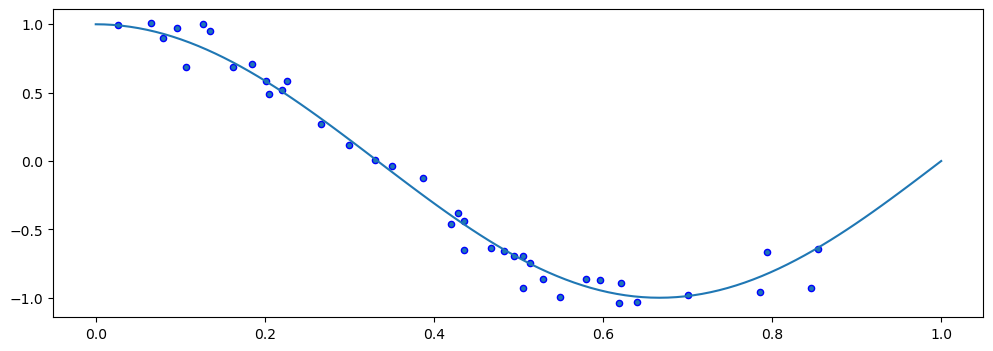

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def true_fn(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(2)
n_samples = 40
X = np.sort(np.random.rand(n_samples))
y = true_fn(X) + np.random.randn(n_samples) * 0.1

X_test = np.linspace(0, 1, 100)
plt.plot(X_test, true_fn(X_test), label="True function")
plt.scatter(X, y, edgecolor='b', s=20, label="Samples")

# Fitting High-Degree Polynomials

Let's see what happens if we fit a high degree polynomial to random samples of 20 points from this dataset.

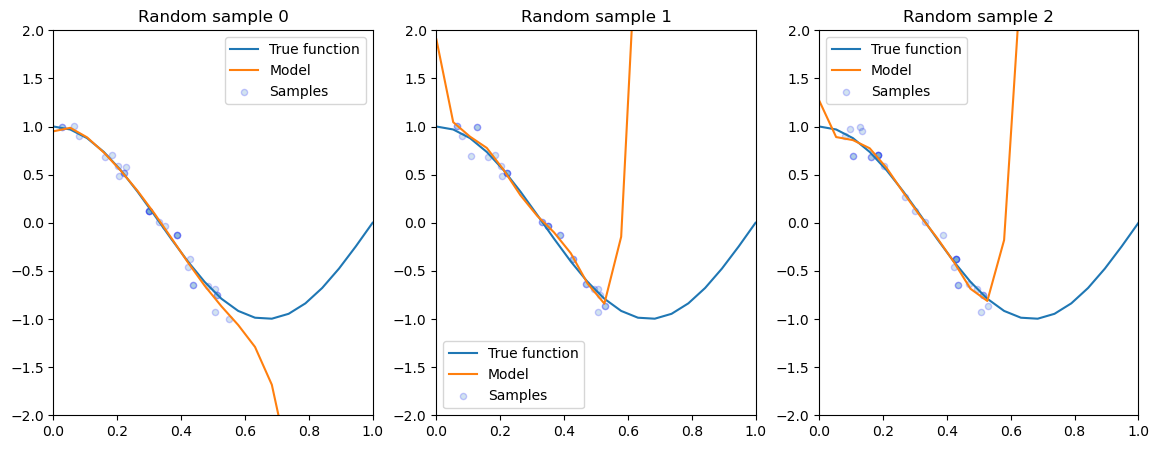

In [7]:
n_plots, X_line = 3, np.linspace(0,1,20)
plt.figure(figsize=(14, 5))
for i in range(n_plots):
    ax = plt.subplot(1, n_plots, i + 1)
    random_idx = np.random.randint(0, 30, size=(30,))
    X_random, y_random = X[random_idx], y[random_idx]

    polynomial_features = PolynomialFeatures(degree=6, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X_random[:, np.newaxis], y_random)

    ax.plot(X_line, true_fn(X_line), label="True function")    
    ax.plot(X_line, pipeline.predict(X_line[:, np.newaxis]), label="Model")
    ax.scatter(X_random, y_random, edgecolor='b', s=20, label="Samples", alpha=0.2)
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="best")
    ax.set_title('Random sample %d' % i)

# High-Variance Models

Each small subset of the data that we train on results is a very different model.

An algorithm that has a tendency to overfit is also called *high-variance*, because it outputs a predictive model that varies a lot if we slightly perturb the dataset.

# Bagging: Bootstrap Aggregation

The idea of *bagging* is to reduce model variance by averaging many models trained on random subsets of the data.

```python
for i in range(n_models):
    # collect data samples and fit models
    X_i, y_i = sample_with_replacement(X, y, n_samples)
    model = Model().fit(X_i, y_i)
    ensemble.append(model)

# output average prediction at test time:
y_test = ensemble.average_prediction(x_test)
```
The data samples are taken with replacement and known as bootstrap samples.

# Bagged Polynomial Regression

Let's apply bagging to our polynomial regression problem.

We are going to train a large number of polynomial regressions on random subsets of the dataset of points that we created earlier.

We start by training an ensemble of bagged models.

In [8]:
n_models, n_subset = 10000, 30
ensemble, Xs, ys = [], [], []
for i in range(n_models):
    # take a random subset of the data
    random_idx = np.random.randint(0, 30, size=(n_subset,))
    X_random, y_random = X[random_idx], y[random_idx]

    # train a polynomial regression model
    polynomial_features = PolynomialFeatures(degree=6, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X_random[:, np.newaxis], y_random)

    # add it to our set of bagged models
    ensemble += [pipeline]
    Xs += [X_random]
    ys += [y_random]

Let's visualize the prediction of the bagged model on each random dataset sample and compare to predictions from an un-bagged models.

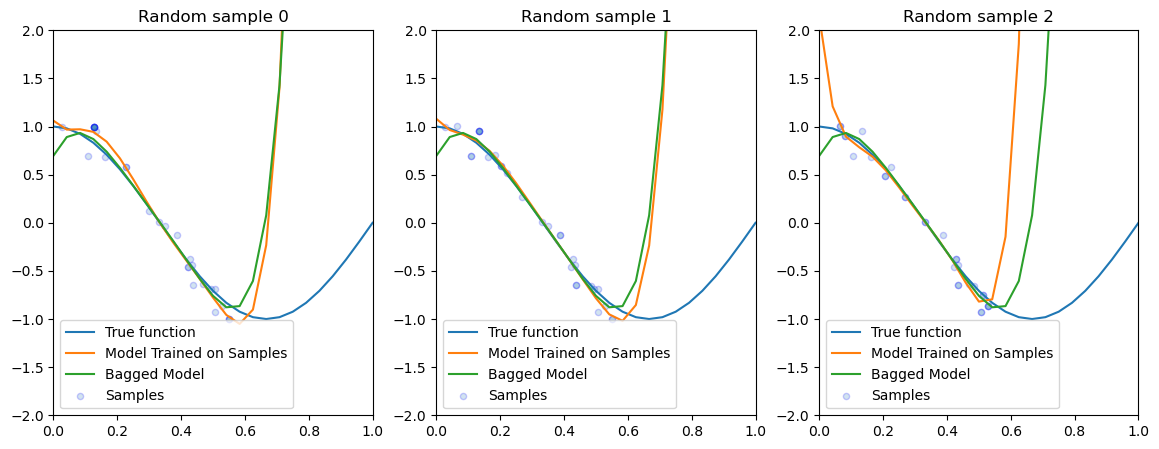

In [9]:
n_plots, X_line = 3, np.linspace(0,1,25)
plt.figure(figsize=(14, 5))
for i in range(n_plots):
    ax = plt.subplot(1, n_plots, i + 1)

    # generate average predictions
    y_lines = np.zeros((25, n_models))
    for j, model in enumerate(ensemble):
        y_lines[:, j] = model.predict(X_line[:, np.newaxis])
    y_line = y_lines.mean(axis=1)

    # visualize them
    ax.plot(X_line, true_fn(X_line), label="True function")    
    ax.plot(X_line, y_lines[:,i], label="Model Trained on Samples")
    ax.plot(X_line, y_line, label="Bagged Model")
    ax.scatter(Xs[i], ys[i], edgecolor='b', s=20, label="Samples", alpha=0.2)
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="best")
    ax.set_title('Random sample %d' % i)

# Extensions of Bagging

There exist a few closely related techniques to bagging.
* Pasting is when samples are taken without replacement.
* Random features are when we randomly sample the features.
* Random patching is when we do both of the above.

# Summary: Bagging

Bagging is a general technique that can be used with high-variance ML algorithms.

It averages predictions from multiple models trained on random subset of the data.

<left><img width=25% src="img/gw_monogram_2c.png"></left>
# Part 4: Random Forests

Next, let's see how bagging can be applied to decision trees. This will also provide us with a new algorithm.


# Review: Bagging

The idea of *bagging* is to reduce model variance by averaging many models trained on random subsets of the data.

```python
for i in range(n_models):
    # collect data samples and fit models
    X_i, y_i = sample_with_replacement(X, y, n_samples)
    model = Model().fit(X_i, y_i)
    ensemble.append(model)

# output average prediction at test time:
y_test = ensemble.average_prediction(y_test)
```
The data samples are taken with replacement and known as bootstrap samples.

# Review: Decision Trees

A decision tree is a model $f : \mathcal{X} \to \mathcal{Y}$ of the form
$$ f(x) = \sum_{R \in \mathcal{R}} y_R \mathbb{I}\{x \in R\}. $$
* The $\mathbb{I}\{\cdot\}$ is an indicator function (one if $\{\cdot\}$ is true, else zero) and values $y_R \in \mathcal{Y}$ are the outputs for that region.
* The set $\mathcal{R}$ is a collection of decision regions. They are obtained by *recursive binary splitting*.
* The rules defining the regions $\mathcal{R}$ can be organized into a tree, with one rule per internal node and regions being the leaves.

We can also illustrate decision trees via this figure from Hastie et al.

<left><img width=50% src="img/decision_tree.png"></left>

# Gas Identification with Trees

We compare a decision tree and a random forest on the six-class gas-identification problem.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

try:
    from slides.course_data import load_gas_sensor_drift
except ModuleNotFoundError:
    from course_data import load_gas_sensor_drift

gas_data = load_gas_sensor_drift(as_frame=True)
rng = np.random.default_rng(12)
sample_indices = np.concatenate([
    rng.choice(np.flatnonzero(gas_data.target.to_numpy() == class_id), 250, replace=False)
    for class_id in range(len(gas_data.target_names))
])

X_raw = gas_data.data.iloc[sample_indices, [8, 9]].to_numpy()
X_array = StandardScaler().fit_transform(np.sign(X_raw) * np.log1p(np.abs(X_raw)))
sensor_X = pd.DataFrame(
    X_array,
    columns=["Transformed sensor 2 response", "Transformed sensor 2 normalized response"],
)
sensor_y = pd.Series(gas_data.target.to_numpy()[sample_indices], name="gas_id")

print(gas_data.DESCR)


In [ ]:
pd.DataFrame({
    "sensor_2_DR": X_raw[:, 0],
    "sensor_2_normalized_DR": X_raw[:, 1],
    "gas": gas_data.target_names[sensor_y.to_numpy()],
}).head()


In [ ]:
p1 = plt.scatter(
    sensor_X.iloc[:, 0], sensor_X.iloc[:, 1], c=sensor_y,
    s=25, cmap="tab10", edgecolor="k", linewidth=0.2
)
plt.xlabel(sensor_X.columns[0])
plt.ylabel(sensor_X.columns[1])
handles, _ = p1.legend_elements()
plt.legend(handles, gas_data.target_names, loc="upper left", fontsize=8)
plt.show()


# Decision Tree on Sensor Measurements

A decision tree partitions the two-dimensional feature space using axis-aligned rules.


The functions below display the decision regions of a fitted classifier.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import warnings

warnings.filterwarnings("ignore")

def make_grid(X, step=0.04):
    x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
    y_min, y_max = X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step), np.arange(y_min, y_max, step)
    )
    return xx, yy

def make_2d_preds(classifier, X):
    xx, yy = make_grid(X)
    return classifier.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

def make_2d_plot(ax, predictions, X, y):
    xx, yy = make_grid(X)
    ax.pcolormesh(xx, yy, predictions, cmap="Pastel1", shading="auto", alpha=0.65)
    ax.scatter(
        X.iloc[:, 0], X.iloc[:, 1], c=y,
        cmap="tab10", edgecolor="k", linewidth=0.2, s=22
    )
    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())


We may now train and visualize a decision tree on this dataset.

In [ ]:
ax = plt.gca()
X = sensor_X
clf = DecisionTreeClassifier(random_state=4)
clf.fit(X, sensor_y)
Z = make_2d_preds(clf, X)
make_2d_plot(ax, Z, X, sensor_y)
plt.show()


# Two Properties of Deep Decision Trees

* The decision regions are axis-aligned and may be highly fragmented.
* A deep tree can fit small variations in the training sample.

The second property produces high model variance.


# High-Variance Decision Trees

When the trees have sufficiently high depth, they can quickly overfit the data.

Recall that this is called the *high variance* problem, because small perturbations of the data lead to large changes in model predictions.

Consider a decision tree fitted to three random subsets of the same sensor dataset.


In [ ]:
n_plots, n_measurements, n_samples = 3, sensor_X.shape[0], 300
plt.figure(figsize=(14, 4))
rng = np.random.default_rng(1000)

for i in range(n_plots):
    ax = plt.subplot(1, n_plots, i + 1)
    random_idx = rng.choice(n_measurements, size=n_samples, replace=True)
    X_random = sensor_X.iloc[random_idx]
    y_random = sensor_y.iloc[random_idx]

    tree = DecisionTreeClassifier(random_state=i)
    tree.fit(X_random, y_random)
    Z = make_2d_preds(tree, sensor_X)
    make_2d_plot(ax, Z, sensor_X, sensor_y)
    ax.set_title("Bootstrap sample %d" % (i + 1))

plt.tight_layout()
plt.show()


# Random Forests

A random forest reduces tree variance by combining predictions from many randomized trees.

Each tree is trained using a bootstrap sample and a random subset of candidate features at each split.


Using decision trees as the base models in bagging gives the following random-forest pseudocode:

```python
for i in range(n_models):
    # collect data samples and fit models
    X_i, y_i = sample_with_replacement(X, y, n_samples)
    model = DecisionTree().fit(X_i, y_i)
    random_forest.append(model)

# output average prediction at test time:
y_test = random_forest.average_prediction(y_test)
```

We may implement random forests in python as follows:

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    random_state=1000,
    n_jobs=1,
)
random_forest.fit(sensor_X, sensor_y)


# Random Forest on Sensor Measurements

The forest predicts by aggregating class votes from its trees.


In [ ]:
ax = plt.gca()
Z = make_2d_preds(random_forest, sensor_X)
make_2d_plot(ax, Z, sensor_X, sensor_y)
plt.show()


The ensemble reduces sensitivity to a particular bootstrap sample. The regions remain axis-aligned because the component models are decision trees.


# Algorithm: Random Forests

* __Type__: Supervised learning for regression or classification
* __Model family__: Ensembles of randomized decision trees
* __Objective function__: Squared error, cross-entropy, or Gini impurity at individual splits
* __Optimizer__: Greedy tree construction with bootstrap and feature randomization


# Strengths and Limitations of Random Forests

Strengths:

* Little feature scaling is required.
* Nonlinear interactions are represented automatically.
* Strong performance is common on tabular data.

Limitations:

* A large forest is difficult to interpret as one complete model.
* Predictions are not naturally differentiable.
* The model does not directly exploit spatial or temporal structure in raw signals.
